# Practical SBI-17 - Energy-based scoring and flexible refinement of docking runs

Until now we have performed the docking of proteins using three different methods:
FTDock, ZDOCK and PathDock. In this practical, we are going to explore two
downstream manipulations that can be done on the results of docking programs.

- Firstly, we are going to explore the use of an alternative scoring function to re-rank the scoring poses provided by a docking method. From the previous practical you used the native scoring function of each method, but there are other scoring
functions available that can be used. To that end, we will use the energy-scoring
function of __pyDock__.

- Secondly, as protein are dynamic entities, and so the interaction of proteins, we will apply limited flexibility to refine the docking poses. By applying flexibility, we will refine the dockings (basically by optimizing the side-chain positions), and re-rank the posed base on the refined structures. The __FireDock__ program will be used for the flexible refinement (sidechain optimization). Maybe with this technique the final scores are much better. 

## 1. Energy-based scoring of TolB-Pal complex with PyDock

The TolB and Pal protein complex in E. coli is involved in maintaining the stability of the outer membrane. TolB and Pal are implied in antibiotic resistance. This complex is important because is the target of the colicins antibiotics (protein antibiotics) using this complex to expedite the entrance in the bacteria. Nuclease colicins competitively recruit TolB using their natively disordered regions (NDRs) to disrupt its complex with Pal, which is thought to trigger translocation of the toxin across a locally destabilized.

We will use __pyDock 3.0__ (python enivornment) to perform a complete docking execution, including rigid-body docking and energy-based scoring. We will generate rigid-body docking poses with ZDOCK for this target, which will be scored with energy-based pyDock scoring function. Then, you will have to make your choice and select what you consider to be the best model from our starting pool of docking poses. Finally, RMSD comparison with the real 3-D complex structure will be done to check the results of our results. We could in principle run ZDOCK separately as we did in the
previous practical and then import the results into pyDock.
All pyDock jobs are launched as follow:

`pyDock3 dockname module`

The argument dockname (similar to project name) is arbitrarily chosen by the user. In our example, we will use T26 as dockname. The different modules that can be used in pyDock are listed here:

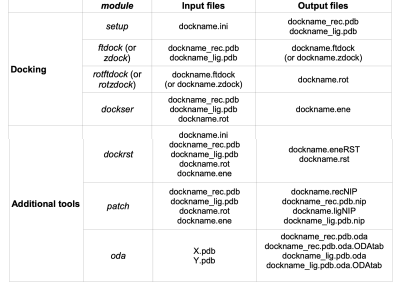

### 1.2 Prepare the input files
Firstly, download the coordinates of the unbound proteins from the protein databank (rcsb.org) and extract the relevant chains for the reference complex (2HQS); no need for the unbound complexes:

1C5K, chain A – Unbound TolB
1OAP, chain A – Unbound Pal
2HQS, chains A, H – Xray TolB-Pal reference complex.

`` awk '$1=="ATOM" && substr($0,22,1)=="A"' 2HQS.pdb > 2hqs_A_H.pdb``

`` awk '$1=="ATOM" && substr($0,22,1)=="H"' 2HQS.pdb >> 2hqs_A_H.pdb ``

Give the following names:
- 1c5k.pdb (TolB, receptor protein)
- 1oap.pdb (Pal, ligand protein)
- 2hqs_A_H.pdb (reference complex)

In addition, you need an ".ini" file, which contains the information about the chains to dock from each PDB file, in order to create a new pair of parsed PDB files suitable for pyDock. Thus, you have to create a text file called `T26.ini` using your favorite text editor and include the following information:

The “mol” chain name is the original chain ID in the input pdb files whereas the “newmol” will be the new chain ID in the parsed pdb files suitable for pyDock. The “newmol” chain names must be different for the receptor and the ligand (so that you can distinguish the chains when docked!). The pdb in the “.ini” file must correspond to the exact names of the pdb files you have.
Once you have a complete T26.ini file, run the pyDock setup using this command in a single line:

`pyDock3 T26 setup`

This command will create the new PDB files for receptor and ligand `T26_rec.pdb` and
`T26_lig.pdb` respectively. These files will be suitable for pyDock.
In case of PDB with incomplete side-chains, these will be automatically rebuilt with SCWRL 3.0 (http://dunbrack.fccc.edu/), which will be automatically launched within pyDock setup, in the pyDock class installation.


### 1.3 Perform the docking using ZDOCK
ZDOCK job can be submitted within pyDock but we will execute ZDOCK as we learned in the previous session:

`/mnt/NFS_UPF/soft/zdock/IntelP3_Linux/zdock -R T26_rec.pdb -L T26_lig.pdb -o T26.zdock`

The docking will run from 10-15 minutes depending on the load of the computer. You can monitor the progress of the job using the command ‘top -c’; look for the zdock process. 

### 1.4. Transform ZDOCK output to pyDock rot file
Upon finishing the docking, you should have the following file in your directory: T26.zdock.
Now, we need to transform the output data from ZDOCK (T26.zdock) to the rotation and
translation matrix that complies with pyDock format. This file will include the rotation and translation information to transform the original coordinates of receptor and ligand in the docked conformation. This is done by using the following command:

`pyDock3 T26 rotzdock`

This calculation is quite fast, and it will create a T26.rot file containing the transformation matrices for all docking poses. Because of time limitations, in this practical we will only proceed with a subset of docking solutions. For that, you need to edit the T26.rot file to keep just 200 conformations.

__IMPORTANT: Before editing the T26.rot file create a copy to save the entire set of
docking solutions. For instance issuing this command:__

`cp T26.rot T26.rot.backup` 

The way you select the 200 docking solutions is up to you. You could for instance extract 200 randomly selected lines from the file using a scripts or the first 200 or the last 200 lines. A little of command line magic could do the trick. To select the top200 or bottom 200 simply do this:

```
head -200 T26.rot.backup > T26.rot

tail -200 T26.rot.backup > T26.rot
```
### 1.5. Scoring using the pyDock energy function
Next stage is to use pyDock energy function to score and rank all positions by running dockser module with the following command:

`pyDock3 T26 dockser`

__WARNING: Be sure you created a T26.rot file with just 200 conformations, otherwise this step would last several hours.__
This step will take a few minutes. You can track the progress of the program on the terminal where you executed the command above.

When dockser finishes, take a look to output file called `T26.ene` that will look like the following example (with different values depending on the 200 docking solution selected):

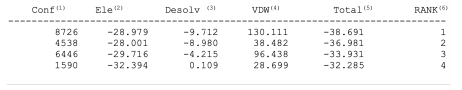

(1) Conf: conformation number of the docking pose (same as that in the rot file, last
column)
(2) Ele: Electrostatic energy component
(3) Delsov: Desolvation energy component
(4) VDW: Van der Waals energy component (term weighted to 0.1 by default)
(5) Total: Total binding energy (Ele + Desolv + 0.1*VDW)
(6) RANK: conformation rank according to its computed binding energy
The ‘Total’ binding energy is the composite scoring function taking into account the contribution of electrostatic, desolvation and VdW components. Note the RANK, indicating the position among all the docking poses according to the pyDock energy function and not to the ZDOCK, even though the docking was done using ZDOCK

### 1.6. Comparison with the real 3D complex structure

### 1.6.1 Generate the top10 docking poses
Now, you can select the most promising docking models taking into account pyDock energy ranking. You can compare the RMSD between the selected models and the real 3D complex structure (PDB 2HQS). Firstly, you have to generate the pdb file of your selected models as follows:

`pyDock3 T26 makePDB 1 10`

This will create pdb files for the docking poses ranked from 1 to 10, as indicated in the “*.ene” file, RANK column. Now check that your files appeared. They will be called as T26_XXXX.pdb, where XXXX is the conformation number as in the T26.ene file (Conf column; first column in the T26.ene file).
As in the previous cases you will need to load the coordinates of the docking poses and reference complex structure (2hqs_A_H.pdb) into Chimera and perform the same type of analyses as before.

ADDITIONAL EXPLORATION
Compare the results of pyDock scoring with the original ZDOCK scoring. __Do you find any change in the number of near-native solutions within the top 10 scored models? Has the best near-native rank improved after pyDock scoring?__

Doing ZDOCK on BASI and savine pdbs:

```
 1767  cp /mnt/NFS_UPF/soft/zdock/IntelP3_Linux/uniCHARMM ./
 1768  cp /mnt/NFS_UPF/soft/zdock/IntelP3_Linux/create_lig ./
 1769  /mnt/NFS_UPF/soft/zdock/IntelP3_Linux/mark_sur savinase.pdb savinase_r.pdb
 1770  /mnt/NFS_UPF/soft/zdock/IntelP3_Linux/mark_sur BASI.pdb BASI_l.pdb
 /mnt/NFS_UPF/soft/zdock/IntelP3_Linux/zdock -R savinase_r.pdb -L BASI_l.pdb -o T26_zdock.out
 ----------
 head -n 14 T26_zdock.out > T26_zdock_10.out
 /mnt/NFS_UPF/soft/zdock/IntelP3_Linux/create.pl T26_zdock_10.out
 mv -v complex.1 complex.1.pdb
mv -v complex.2 complex.2.pdb
etc … up to
mv -v complex.10 complex.10.pdb
```
```
complex.10           RMSD =   21.965 (1727 atoms)
complex.1            RMSD =   23.339 (1727 atoms)
complex.2            RMSD =   21.479 (1727 atoms)
complex.3            RMSD =   23.118 (1727 atoms)
complex.4            RMSD =   22.486 (1727 atoms)
complex.5            RMSD =   24.313 (1727 atoms)
complex.6            RMSD =   24.202 (1727 atoms)
complex.7            RMSD =   23.586 (1727 atoms)
complex.8            RMSD =   21.657 (1727 atoms)
complex.9            RMSD =   21.046 (1727 atoms)
```

And compared with pyDock results: (higher number of atoms is due to more protons)

```
T26_105              RMSD =   16.513 (3843 atoms)
T26_110              RMSD =   14.868 (3843 atoms)
T26_114              RMSD =   14.857 (3843 atoms)
T26_120              RMSD =   14.805 (3843 atoms)
T26_139              RMSD =   17.121 (3843 atoms)
T26_176              RMSD =   18.647 (3843 atoms)
T26_184              RMSD =   15.121 (3843 atoms)
T26_192              RMSD =   14.557 (3843 atoms)
T26_96               RMSD =   18.151 (3843 atoms)
T26_99               RMSD =   18.148 (3843 atoms)
```

The document notes that ZDOCK is an exhaustive search primarily based on shape complementarity and simplified electrostatics. pyDock is a "rescoring" protocol. It takes the poses generated by a program like ZDOCK and applies a more sophisticated energy function that includes:

- Electrostatics (Coulomb energy)

- Desolvation energy

- Van der Waals interactions

Because pyDock uses a more physically realistic energy calculation than the initial fast FFT search, it is much better at "picking out" the true native-like orientations from the list of candidates and moving them to the top of the rankings.

## 2. PATCHDOCK/FIREDOCK: SAVINASE-BASI COMPLEX

In this exercise we will work with the Savinase/Basi complex. Savinase is a secreted microbial serine protease and BASI is a Savinase inhibitor produced by plants. Hence, BASI has a role in plant defense binding to the protease (Savinase) and preventing its function. Indeed, BASI is produced by plants to protects the seed from pathogen-derived serine proteases including savinase.

In this exercise we will perform a rigid-body docking using PatchDock but then we are going to perform a limited refinement of rigid-body docking models with FireDock. As protein-protein interactions imply certain conformational changes, by doing a flexible refinement we hope to improve both the conformation of the models and the ranking of the docking poses. Important to stress that we will not be doing a fully flexible docking, just simple some localized optimization in the form of side-chain flexibility.

• savinase.pdb - The structure of the protease in PDB format (chain A).
• BASI.pdb - The structure of the inhibitor in PDB format (chain C).
• NativeComplex.pdb - The structure of the correct native complex (PDB 3bx1).

### 2.1. Rigid docking using PatchDock
#### 2.1.1. Create parameter file for PatchDock
As before we are going to generate a parameter file (params.txt) using the following command
in a single line:

`buildParams.pl savinase.pdb BASI.pdb 4.0 EI`

Note the parameter ‘EI’ stands for Enzyme-Inhibitor complex as such is this case.

#### 2.1.2. Execute the docking

`patch_dock.Linux params.txt out_file2`

This step will take around 15 minutes to finish.

#### 2.1.3. Examine several solutions
Generate top 10 docking models as explained in previous practical and analyze them as
previously using Chimera. 

`transOutput.pl out_file2 1 10`

__Is there any good candidate among the selected ones comparing to the reference complex
(NativeComplex.pdb)?__

```
out_file2.10         RMSD =   15.107 (3113 atoms)
__out_file2.1          RMSD =    9.298 (3241 atoms)__
out_file2.2          RMSD =   10.068 (3227 atoms)
out_file2.3          RMSD =   23.355 (2677 atoms)
out_file2.4          RMSD =   15.709 (3222 atoms)
out_file2.5          RMSD =   14.644 (3202 atoms)
out_file2.6          RMSD =   14.162 (3215 atoms)
out_file2.7          RMSD =   10.185 (3210 atoms)
out_file2.8          RMSD =   13.799 (3218 atoms)
out_file2.9          RMSD =   19.173 (3114 atoms)
```

### 2.2. Refinement of the docking poses using FireDock
In this step, we are going to refine the docking poses generate by PatchDock applying limited
flexibility. This step should in principle improve the docking poses and provide more realistic
docking poses and a better ranking.

#### 2.2.1. Protonate input structures for FireDock
FireDock require that input structures to be protonated, i.e., it needs to include the hydrogen
atoms on each residue. There are different programs that can be used to protonate protein
structures, since we don’t have any available, we provided the protonated version of the input
structures. You can find them in the SBI_17_P folder:

• savinase.pdb.CHB.pdb - Protonated structure of the protease in PDB format (chain A).
• BASI.pdb.CHB.pdb - Protonated structure of the inhibitor in PDB format (chain C).

#### 2.2.2 Build transformation file from PatchDock output
FireDock uses its unique format for the transformation matrix (rotation/translation), which is
different from PatchDock. You can change the format using this command in a single line:

```
/mnt/NFS_UPF/soft/FireDock/PatchDockOut2Trans.pl out_file2 > ex1.trans
```

__WARNING: Be sure you extracted just the top 200 poses from ex1.trans file, otherwise__

the next step will be running for a long time! For instance, like this:

```
head -200 ex1.trans > tmp
mv tmp ex1.trans
```
#### 2.2.3. Create parameter file for FireDock
Create parameter file (paramsREF.txt) needed by FireDock. In this case and given the time constraints, we will be doing a "coarse" refinement (RISCO, 50 cycles of RBO and radiiScale=0.8), with the option "1" to save the refined conformations to PDB files. Issue the following command in a single line:

```
/mnt/NFS_UPF/soft/FireDock/buildFireDockParams.pl savinase.pdb.CHB.pdb BASI.pdb.CHB.pdb U U EI ex1.trans firedock.out 0 50 0.8 1 paramsREF.txt
```
#### 2.2.4. Execute the refinement
Finally, execute the refinement with the next command in single line:

```
/mnt/NFS_UPF/soft/FireDock/runFireDock.pl paramsREF.txt
```

This step will take between 10-20 minutes depending on the CPU load. As before, you can track the progress of the program by inspecting the output in the terminal where you executed the command

#### 2.2.5. Examine your results
Upon finishing two new files will be create:

```
firedock.out.unref (before refinement)
firedock.out.ref (after refinement) #tells new scores once applied refinement
```


Inside the firedock.out.ref:

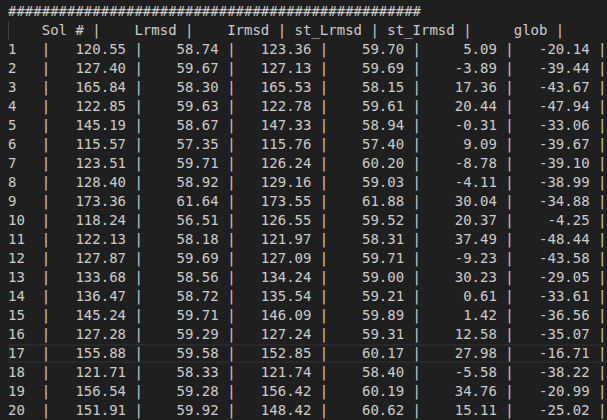



These files contain information on the different scoring terms and refinement performed by FireDock. Of special interest is the 11th Column ‘glob’, which is the global score. There will be also 200 additional PDB files have been also generated upon the refinement of you docking poses selected from PatchDock (firedock.out_XXX.ref.pdb; XXX: given conformation) .
It will be necessary to sort the list of refined poses: firedock.out.ref. This can be easily achieved using the ‘sort’ Linux command as follow (in a single line)

`sort -n -k11 firedock.out.ref > firedock.out.ref_sorted`

Inside the firedock.out.ref.sorted:

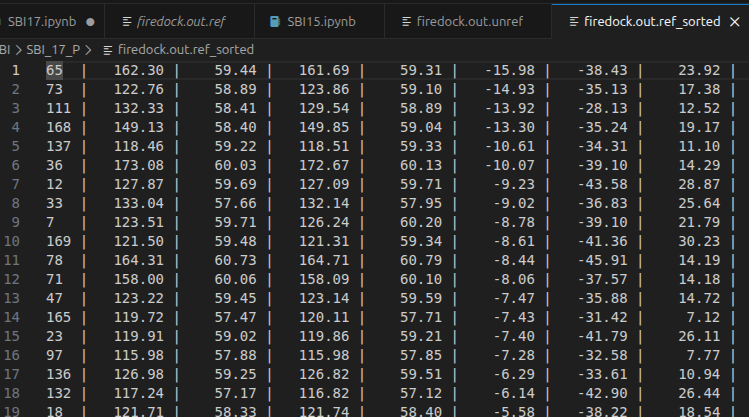

The file firedock.out.ref_sorted will now contain the list of refined poses numerically (-n) sorted by the 11th column (-k 11). Remember that 11th column correspond to ‘glob’, which is the global score.

As usual, load the docking poses and the reference complex in Chimera and analyze them.
Particularly to this exercise consider:

- __Visualize the top 10 refined solutions (according to "glob" energy value) and compare them to the rigid-body docking solutions (before refinement) and to the reference complex (NativeComplex.pdb).__

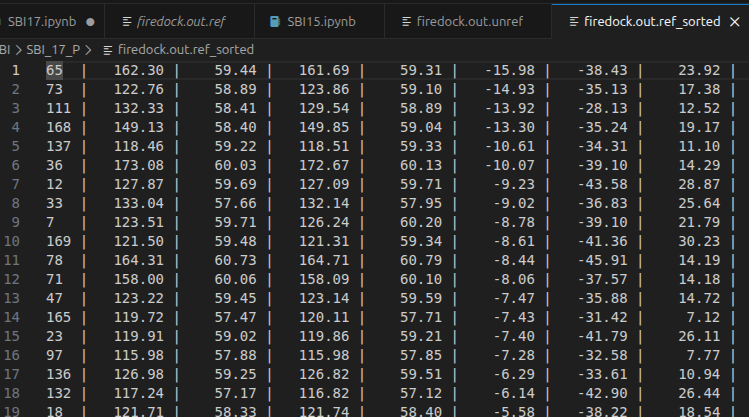
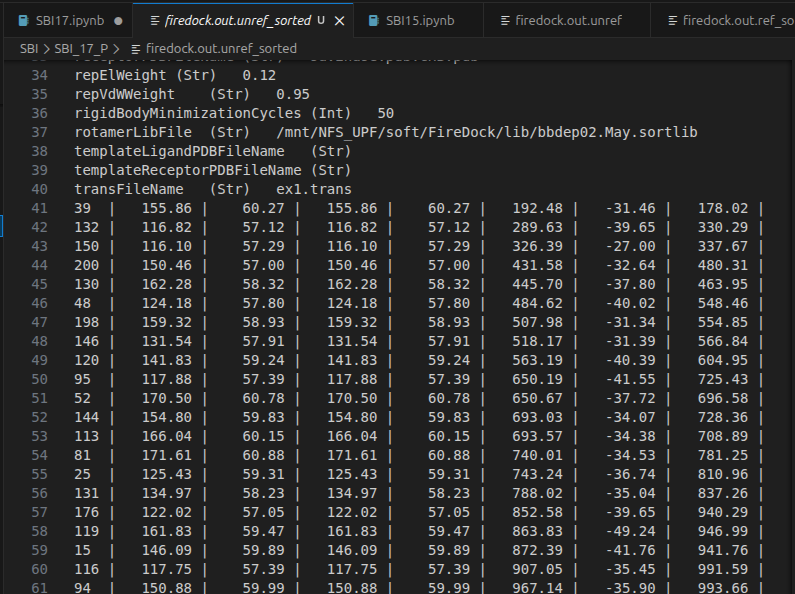

For the refinement sorted:
```
firedock.out_65.ref  RMSD =   19.633 (3222 atoms)
firedock.out_73.ref  RMSD =   17.281 (3213 atoms)
firedock.out_111.ref RMSD =   10.713 (3241 atoms)
firedock.out_168.ref RMSD =   15.943 (3210 atoms)
firedock.out_36.ref  RMSD =   19.955 (3118 atoms)
firedock.out_12.ref  RMSD =   10.556 (3227 atoms)
firedock.out_33.ref  RMSD =   18.526 (3241 atoms)
firedock.out_7.ref   RMSD =   10.627 (3115 atoms)
firedock.out_169.ref RMSD =    8.704 (3241 atoms)
```

For the unrefinement sorted:

`pymol firedock.out_39.ref.pdb firedock.out_132.ref.pdb firedock.out_150.ref.pdb firedock.out_200.ref.pdb firedock.out_130.ref.pdb firedock.out_48.ref.pdb firedock.out_198.ref.pdb firedock.out_146.ref.pdb firedock.out_120.ref.pdb NativeComplex.pdb`

```
firedock.out_39.ref  RMSD =   18.234 (3113 atoms)
firedock.out_132.ref RMSD =   14.443 (3222 atoms)
firedock.out_150.ref RMSD =   14.073 (3114 atoms)
firedock.out_200.ref RMSD =   18.541 (3218 atoms)
firedock.out_130.ref RMSD =   21.108 (3119 atoms)
firedock.out_48.ref  RMSD =   16.432 (3254 atoms)
firedock.out_198.ref RMSD =   21.065 (3111 atoms)
firedock.out_146.ref RMSD =   12.202 (3201 atoms)
firedock.out_120.ref RMSD =   19.368 (3102 atoms)
```

Before refinement, PatchDock output:

```
pymol out_file2.*.pdb NativeComplex.pdb

out_file2.10         RMSD =   15.107 (3113 atoms)
out_file2.1          RMSD =    9.298 (3241 atoms)
out_file2.2          RMSD =   10.068 (3227 atoms)
out_file2.3          RMSD =   23.355 (2677 atoms)
out_file2.4          RMSD =   15.709 (3222 atoms)
out_file2.5          RMSD =   14.644 (3202 atoms)
out_file2.6          RMSD =   14.162 (3215 atoms)
out_file2.7          RMSD =   10.185 (3210 atoms)
out_file2.8          RMSD =   13.799 (3218 atoms)
out_file2.9          RMSD =   19.173 (3114 atoms)

```

For the refinement sorted:

```
pymol firedock.out_65.ref.pdb firedock.out_73.ref.pdb firedock.out_111.ref.pdb firedock.out_168.ref.pdb firedock.out_36.ref.pdb firedock.out_12.ref.pdb firedock.out_33.ref.pdb firedock.out_7.ref.pdb firedock.out_169.ref.pdb NativeComplex.pdb 

firedock.out_65.ref  RMSD =   19.633 (3222 atoms)
firedock.out_73.ref  RMSD =   17.281 (3213 atoms)
firedock.out_111.ref RMSD =   10.713 (3241 atoms)
firedock.out_168.ref RMSD =   15.943 (3210 atoms)
firedock.out_36.ref  RMSD =   19.955 (3118 atoms)
firedock.out_12.ref  RMSD =   10.556 (3227 atoms)
firedock.out_33.ref  RMSD =   18.526 (3241 atoms)
firedock.out_7.ref   RMSD =   10.627 (3115 atoms)
firedock.out_169.ref RMSD =    8.704 (3241 atoms)
```
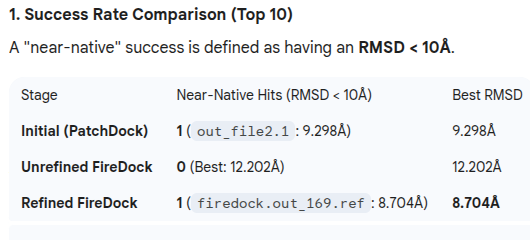

- __Have the success rate of the top 10 docking solutions improved after refinement? i.e. have you increases the number of docking poses among the top 10 with smaller RMSD with respect to reference complex.__

Unrefined vs. Refined: The "Refined" process was highly successful at re-ranking. It took a pose that was initially ranked 169 (firedock.out_169)—which would have been ignored in a top-10 analysis—and used energy minimization to identify it as a high-quality interaction. It pulled this pose up into the top 10 (Rank 9).

- __Which rank and RMSD have the near-native solutions after refinement? if there were not any near-native solutions in the rigid-body set, just apply this question to the best solution in terms of RMSD.__
In docking terminology, a "near-native" solution is typically defined as one with an RMSD < 10Å.

Looking at your list, there is only one near-native solution in the top 10 refined results:

- Rank: 9 (file: firedock.out_169.ref)

- RMSD: 8.704 Å

- __Does full refinement provide better results than default (restricted) refinement?__

1. Restricted (Default) Refinement
In this mode, the program treats the protein backbones as frozen. It only optimizes the side-chain conformations.

The Limitation: If the initial rigid-body docking (from PatchDock or ZDOCK) placed the ligand even slightly too far or at a slightly wrong angle, restricted refinement cannot "fix" that placement. It can only rotate the "arms" (side chains) to try and find a better energy score within that specific, potentially flawed, position.

2. Full Refinement
Full refinement optimizes the side chains and performs small-scale rigid-body movements (translations and rotations).

The Advantage: It allows the ligand to "breathe" and "settle" into the receptor. If there is a clash that cannot be fixed by moving a side chain, full refinement allows the entire protein to shift slightly to resolve the conflict. This allows the system to reach the Global Minimum—the lowest possible energy state—rather than getting stuck in a local, less stable one.